[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hankpark0706/OL7014/blob/main/notebooks/week1_knapsack.ipynb)

In [1]:
%pip install -q gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 72.5 MB/s eta 0:00:00


In [9]:
import gurobipy as gp
from gurobipy import GRB

params = {
    "WLSACCESSID": "여기에 ACCESSID 붙여넣기",
    "WLSSECRET":   "여기에 SECRET 붙여넣기",
    "LICENSEID":   123456,   # 숫자 그대로, 따옴표 없이
}
env = gp.Env(params=params)


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2857293
Academic license 2857293 - for non-commercial use only - registered to lo___@gmail.com


# First model — a toy LP

$$
\begin{aligned}
\max_{x,\,y} \quad & 4x + 5y \\
\text{s.t.} \quad & x + 3y \le 10 \\
                  & 3x + y \le 10 \\
                  & x,\, y \ge 0
\end{aligned}
$$

**Math to code**

| math | code |
| :--- | :--- |
| $x,\,y \ge 0$ | free — `addVar` lower bound is already `0` |
| $\max\; 4x + 5y$ | `setObjective(expr, GRB.MAXIMIZE)` — expression **and** sense |
| each $\le$ row | one `addConstr` — same coefficients, same order |

## Live coding — fill in the blanks

Skeleton for building the model live in class, one comment at a time.

In [ ]:
# Initialize the model gp.Model()


# decision variables, we have two continuous variables --- e.g., lp.addVar(vtype=GRB.CONTINUOUS), lp.addVar(vtype=GRB.BINARY)


# let's define objective function --- lp.setObjective()


# now constraints, one per row of the math --- lp.addConstr()


# Model is set up. Let's optimize --- lp.optimize()


# Let's print x, y and the objective value --- e.g., GREEN = "\033[92m"; RESET = "\033[0m"


## Reference: the completed model

In [5]:
lp = gp.Model("warmup_lp")

# decision variables -- continuous, lower bound 0 by default
x = lp.addVar(vtype=GRB.CONTINUOUS, name="x")
y = lp.addVar(vtype=GRB.CONTINUOUS, name="y")

# objective -- max 4x + 5y
lp.setObjective(4 * x + 5 * y, GRB.MAXIMIZE)

# constraints -- one line per row of the math
lp.addConstr(x + 3 * y <= 10, name="c1")
lp.addConstr(3 * x + y <= 10, name="c2")

lp.optimize()

print(f"\nx = {x.X:.2f}   y = {y.X:.2f}")
print(f"objective = {lp.ObjVal:.2f}")

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros (Max)
Model fingerprint: 0xb404306d
Model has 2 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 3e+00]
  Objective range  [4e+00, 5e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 1e+01]

Presolve time: 0.00s
Presolved: 2 rows, 2 columns, 4 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    9.0000000e+30   2.000000e+30   9.000000e+00      0s
       2    2.2500000e+01   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.250000000e+01

x = 2.50   y = 2.50
objective = 22.50


## Draw it

- **shaded** — feasible set: both constraints, plus $x,\,y \ge 0$
- **dashed** — objective $4x + 5y = 22.5$, pushed up-right until it leaves
- **star** — optimum $(2.5,\; 2.5)$

**The optimum sits on a corner.** True of every LP, at any number of variables.

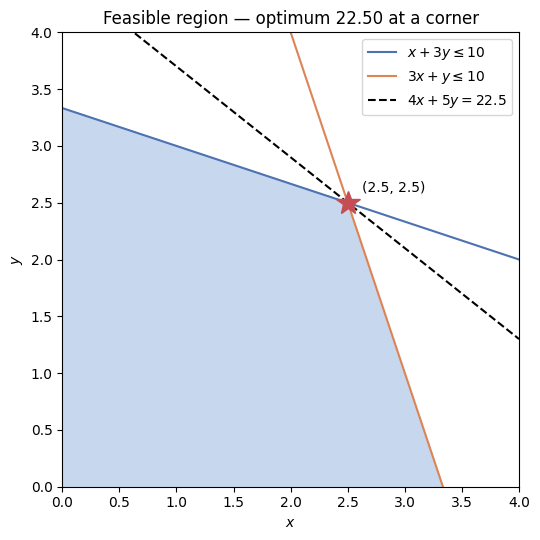

In [6]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(0, 4, 400)
XX, YY = np.meshgrid(grid, grid)
feasible = ((XX + 3 * YY <= 10) & (3 * XX + YY <= 10)).astype(float)

plt.figure(figsize=(5.5, 5.5))
plt.contourf(XX, YY, feasible, levels=[0.5, 1.5], colors=["#AEC7E8"], alpha=0.7)
plt.plot(grid, (10 - grid) / 3, color="#4C72B0", label=r"$x + 3y \leq 10$")
plt.plot(grid, 10 - 3 * grid, color="#DD8452", label=r"$3x + y \leq 10$")

# the objective line through the optimum: 4x + 5y = ObjVal
plt.plot(grid, (lp.ObjVal - 4 * grid) / 5, "k--",
         label=rf"$4x + 5y = {lp.ObjVal:.1f}$")
plt.plot(x.X, y.X, "*", color="#C44E52", markersize=18, zorder=5)
plt.annotate(f"({x.X:.1f}, {y.X:.1f})", (x.X, y.X),
             textcoords="offset points", xytext=(10, 8))

plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(f"Feasible region — optimum {lp.ObjVal:.2f} at a corner")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Now force $x,\,y$ to be whole numbers

|  | $x$ | $y$ | $x+3y \le 10$ | $3x+y \le 10$ | objective |
| :--- | ---: | ---: | :---: | :---: | ---: |
| LP | 2.5 | 2.5 | ok | ok | 22.5 |
| round down | 2 | 2 | 8 ok | 8 ok | 18 |
| round up $x$ | 3 | 2 | 9 ok | 11 **no** | infeasible |
| round up $y$ | 2 | 3 | 11 **no** | --- | infeasible |
| round both up | 3 | 3 | 12 **no** | --- | infeasible |
| **true IP** | **1** | **3** | 10 ok | 6 ok | **19** |

Rounding down *happens* to stay feasible here, and still **loses a point**. The other three roundings are **infeasible**. So rounding can cost you feasibility *and* optimality — in $n$ variables there are $2^n$ candidates and all of them can fail. And nothing in the LP answer points at $(1,\,3)$.

That gap is the whole course. In code, one keyword:

In [7]:
ip = gp.Model("warmup_ip")

# same model, one keyword different: INTEGER instead of CONTINUOUS
x_int = ip.addVar(vtype=GRB.INTEGER, name="x")
y_int = ip.addVar(vtype=GRB.INTEGER, name="y")

ip.setObjective(4 * x_int + 5 * y_int, GRB.MAXIMIZE)
ip.addConstr(x_int + 3 * y_int <= 10, name="c1")
ip.addConstr(3 * x_int + y_int <= 10, name="c2")

ip.optimize()

print(f"\nLP : x = {x.X:.2f}, y = {y.X:.2f}   ->  {lp.ObjVal:.2f}")
print(f"IP : x = {x_int.X:.0f}, y = {y_int.X:.0f}   ->  {ip.ObjVal:.0f}")

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros (Max)
Model fingerprint: 0xb406eaad
Model has 2 linear objective coefficients
Variable types: 0 continuous, 2 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+00]
  Objective range  [4e+00, 5e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 1e+01]

Found heuristic solution: objective 17.0000000
Presolve time: 0.00s
Presolved: 2 rows, 2 columns, 4 nonzeros
Variable types: 0 continuous, 2 integer (0 binary)

Root relaxation: objective 2.050000e+01, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   20.50000    0    1   17

# Knapsack — a 0/1 integer program

Rucksack, capacity **21 kg**, 6 items, each taken whole or left behind $\Rightarrow x_j \in \{0,\,1\}$.

| item | weight (kg) | value (pts) |
| :--- | ---: | ---: |
| rifle   | 5 | 9 |
| boots   | 7 | 8 |
| helmet  | 8 | 9 |
| canteen | 8 | 8 |
| medkit  | 8 | 3 |
| rations | 2 | 9 |

$x_j = 1$ means item $j$ is packed.

$$
\begin{aligned}
\max_{x} \quad
  & 9x_{\text{rifle}} + 8x_{\text{boots}} + 9x_{\text{helmet}}
    + 8x_{\text{canteen}} + 3x_{\text{medkit}} + 9x_{\text{rations}} \\
\text{s.t.} \quad
  & 5x_{\text{rifle}} + 7x_{\text{boots}} + 8x_{\text{helmet}}
    + 8x_{\text{canteen}} + 8x_{\text{medkit}} + 2x_{\text{rations}} \;\le\; 21 \\
  & x_j \in \{0,\,1\}
\end{aligned}
$$

objective coefficients = **value** column, constraint coefficients = **weight** column

## Live coding — fill in the blanks

Skeleton for building the model live in class, one comment at a time.

In [ ]:
m = gp.Model("Knapsack")

# decision variables, we have six binary variables --- e.g., m.addVar(vtype=GRB.BINARY), m.addVar(vtype=GRB.CONTINUOUS)


# let's define objective function --- m.setObjective()


# now constraints --- m.addConstr()


# Model is set up. Let's optimize --- m.optimize()


# Let's print the optimal solution

## Reference: the completed model

By hand — no dictionaries, no loops, no `quicksum` — so every term matches the math above.

In [8]:
m = gp.Model("knapsack")

# decision variables -- one binary per item
x_rifle   = m.addVar(vtype=GRB.BINARY, name="x_rifle")
x_boots   = m.addVar(vtype=GRB.BINARY, name="x_boots")
x_helmet  = m.addVar(vtype=GRB.BINARY, name="x_helmet")
x_canteen = m.addVar(vtype=GRB.BINARY, name="x_canteen")
x_medkit  = m.addVar(vtype=GRB.BINARY, name="x_medkit")
x_rations = m.addVar(vtype=GRB.BINARY, name="x_rations")

# objective -- total value (pts), written out term by term
m.setObjective(
    9 * x_rifle + 8 * x_boots + 9 * x_helmet + 8 * x_canteen + 3 * x_medkit + 9 * x_rations,
    GRB.MAXIMIZE,
)

# constraint -- total weight (kg) within the 21 kg capacity, written out term by term
m.addConstr(
    5 * x_rifle + 7 * x_boots + 8 * x_helmet + 8 * x_canteen + 8 * x_medkit + 2 * x_rations <= 21,
    name="capacity",
)

m.optimize()

print(f"\nrifle={x_rifle.X:.0f}  boots={x_boots.X:.0f}  helmet={x_helmet.X:.0f}  "
      f"canteen={x_canteen.X:.0f}  medkit={x_medkit.X:.0f}  rations={x_rations.X:.0f}")
print(f"value = {m.ObjVal:.0f} pts")

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1 rows, 6 columns and 6 nonzeros (Max)
Model fingerprint: 0x2b38cc68
Model has 6 linear objective coefficients
Variable types: 0 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [2e+00, 8e+00]
  Objective range  [3e+00, 9e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+01, 2e+01]

Found heuristic solution: objective 26.0000000
Presolve removed 1 rows and 6 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 2 available processors)

Solution count 2: 27 26 

Optimal solution found (tolerance 1.00e-04)
Best objective 2.700000000000e+01, best bound 2.700000000000e+01, gap 0.0000%

rifle=1  boots=0  he

## Plot the solution

One bar per item, height $= x_j$ — 1 packed, 0 left behind.

Later: the same plot for the **LP relaxation**, where bars land anywhere in $[0,\,1]$ — the knapsack version of $(2.5,\; 2.5)$.

In [ ]:
import matplotlib.pyplot as plt

items = ["rifle", "boots", "helmet", "canteen", "medkit", "rations"]
x_vals = [x_rifle.X, x_boots.X, x_helmet.X, x_canteen.X, x_medkit.X, x_rations.X]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#CCB974"]

plt.figure(figsize=(6, 4))
plt.bar(items, x_vals, color=colors)
plt.ylim(0, 1.1)
plt.ylabel("packed? ($x_j$)")
plt.title(f"Optimal packing — value = {m.ObjVal:.0f} pts")
plt.tight_layout()
plt.show()

## Same model, less typing — dict + `gp.quicksum`

Hand-typing does not scale: 20 items means 20 variable lines and two 20-term sums.

Loop over a dictionary instead — same answer, harder to see which term is which. Commented out for now.

In [ ]:
# items = {
#     "rifle":   (5, 9),   # (weight kg, value pts)
#     "boots":   (7, 8),
#     "helmet":  (8, 9),
#     "canteen": (8, 8),
#     "medkit":  (8, 3),
#     "rations": (2, 9),
# }
# CAPACITY = 21
#
# m2 = gp.Model("knapsack_dict")
# x = m2.addVars(items.keys(), vtype=GRB.BINARY, name="x")
# m2.setObjective(gp.quicksum(items[j][1] * x[j] for j in items), GRB.MAXIMIZE)
# m2.addConstr(gp.quicksum(items[j][0] * x[j] for j in items) <= CAPACITY, name="capacity")
# m2.optimize()
# print([j for j in items if x[j].X > 0.5], m2.ObjVal)